# Full scattering rate $R(m_\chi)$ from $dR/dq$ — N-site lattice, long-wavelength, massive mediator

This notebook **extracts the $dR/dq$ computation methods** behind three quantities from
`ScatteringRate_NSiteLattice_longwavelength_massiveMediator.ipynb`

| variable | meaning |
|---|---|
| `dRdq_result_incoh_4plot` | incoherent (diagonal) structure-factor $dR/dq$ |
| `drdq_result_lwa_allqanalytic_4plot` | analytic long-wavelength (LWA) 1st order **everywhere** + numeric 2nd-and-higher (coherent) |
| `drdq_result_lwa_qbzanalytic_4plot` | analytic LWA 1st order for $q<q_{BZ}$, incoherent for $q\ge q_{BZ}$, + numeric 2nd-and-higher (incoherent) |

and then **integrates each $dR/dq$ over $q$** to get the full isotropic rate

$$R(m_\chi)=\int dq\,\frac{dR}{dq},\qquad
\frac{dR}{dq}=\frac{1}{\rho_T}\frac{\rho_\chi}{m_\chi}\frac{\pi\bar\sigma(q)}{\mu_\chi^2}\frac{q}{(2\pi)^2}\int d\omega\,\eta\big(v_{min}(q,\omega)\big)\,S(q,\omega)$$

for **three detector-threshold cuts** $\omega_{th}\in\{1,10,20\}$ meV and a grid of DM masses, producing the
$R$ vs DM-mass plot.

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Manuscript plotting style
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.size': 15,
})

## 1. Configuration

* `SF_NPZ` — the saved N-site structure factors (`s_tot`, `s_diag`, `qlist`, `omegalist`).
* `FIRST_ORDER_NPZ` — cached numeric **1st-order** structure factors (`finalres_1st`, `finalresdiag_1st`).
  These are needed to build the *2nd-and-higher* pieces (`s_tot - 1st`).  They are computed once with
  `StructureFactor1D` and cached, because that recursion is slow.
* `CUTS` — the detector energy thresholds $\omega_{th}$ ("cuts").
* `DMMASSLIST` — DM masses for the $R$ vs mass curve.

In [2]:
# --- file paths (edit to match your machine) -------------------------------
SF_NPZ          = "./nSiteSFactor_lwa_drdq.npz"   # has: s_tot, s_diag, s_lwa, qlist, omegalist
FIRST_ORDER_NPZ = "./nSite1stOrderr.npz"           # cache for finalres_1st / finalresdiag_1st
STRUCTUREFACTOR1D_PATH = r"C:/Users/xylin/Documents/Researches/multiphonon-direct-detection"

# --- physics / numerics ----------------------------------------------------
cross_section = 1e-40        # cm^2  (assumed reference; R is linear in it)
omega_avg     = 13.13e-6     # keV   (impulse-approximation average energy)
q_bz          = 1.14         # keV   (Brillouin-zone edge, q_BZ ~ 2 m_chi v)

CUTS = {                      # label -> omega_threshold [keV]
    '1 meV':  1e-6,
    '10 meV': 10e-6,
    '20 meV': 20e-6,
}

# DM mass grid for the R vs mass plot (keV). Increase dm_length for a finer curve.
dm_length  = 60
DMMASSLIST = 10**np.linspace(1, 6, dm_length)   # 10 keV ... 1 GeV

## 2. Load the N-site structure factors

In [3]:
nSiteData = np.load(SF_NPZ)
s_factor_nSite       = nSiteData["s_tot"]    # coherent total  S(q, omega)
s_factor_nSite_incoh = nSiteData["s_diag"]   # incoherent (diagonal) total
q_list_nSite         = nSiteData["qlist"]    # keV
omega_list_nSite     = nSiteData["omegalist"]# keV
print("S(q,omega) shape:", s_factor_nSite.shape,
      "| nq =", len(q_list_nSite), "| nomega =", len(omega_list_nSite))

S(q,omega) shape: (1500, 1000) | nq = 1500 | nomega = 1000


## 3. First-order structure factors → build the *2nd-and-higher* pieces

`s_factor_nSite_2ndandhigher       = s_tot  - (1st-order coherent)`
`s_factor_nSite_2ndandhigher_incoh = s_diag - (1st-order incoherent)`

The first-order arrays are computed once with `StructureFactor1D` and cached to `FIRST_ORDER_NPZ`.
On later runs they are simply loaded.

In [4]:
def compute_first_order_structure_factors(q_list, omega_list, nLattice=100, max_omega=250e-6):
    """Numeric 1st-order S(q,omega): returns (finalresdiag_1st, finalres_1st)."""
    import sys
    if STRUCTUREFACTOR1D_PATH not in sys.path:
        sys.path.append(STRUCTUREFACTOR1D_PATH)
    from StructureFactor1D import StructureFactor1D

    omegalength = len(omega_list)
    res_diag, res_tot = [], []
    for idx, q in enumerate(q_list):
        if idx % 100 == 0:
            print(f"  1st-order q-point {idx}/{len(q_list)}")
        sFacCalc = StructureFactor1D(nLattice=nLattice, q_value=q, couplingConst=28)
        xlist, delta_omega = np.linspace(0, max_omega, omegalength, retstep=True)
        sFacCalc.setup_DoS(max_omega, nBins=1000)
        sFacCalc.init_recursion(print_message=False)          # 1st order
        s_diag = sFacCalc.get_binned_s_diag(xlist, delta_omega)
        s_off  = sFacCalc.get_binned_s_offdiag(xlist, delta_omega)
        res_diag.append(s_diag)
        res_tot.append(s_diag + s_off)
    return np.array(res_diag), np.array(res_tot)


try:
    d = np.load(FIRST_ORDER_NPZ)
    finalresdiag_1st = d["finalresdiag_1st"]
    finalres_1st     = d["finalres_1st"]
    print("Loaded cached 1st-order structure factors.")
except (FileNotFoundError, OSError):
    print("Cache not found — computing 1st-order structure factors with StructureFactor1D ...")
    finalresdiag_1st, finalres_1st = compute_first_order_structure_factors(
        q_list_nSite, omega_list_nSite)
    np.savez(FIRST_ORDER_NPZ,
             finalresdiag_1st=finalresdiag_1st, finalres_1st=finalres_1st)
    print("Saved cache ->", FIRST_ORDER_NPZ)

# 2nd-and-higher = total - 1st order
s_factor_nSite_2ndandhigher       = s_factor_nSite       - finalres_1st
s_factor_nSite_2ndandhigher_incoh = s_factor_nSite_incoh - finalresdiag_1st

Loaded cached 1st-order structure factors.


## 4. Numeric $dR/dq$ engine (`RateCalculations`)

For a fixed $q$ this integrates $\eta(v_{min})\,S(q,\omega)\,q$ over $\omega$ between the threshold and the
kinematic maximum (eqn. 11 of 2108.03239).

In [5]:
N_ATOMS_PER_CELL = 2.0

In [6]:
class RateCalculations:
    def __init__(self, mass_DM, q_val, omega_list, omega_threshold, s_factor, cross_section):
        c = 2.998e5  # km/s
        self.mass_DM = mass_DM
        self.mass_proton = 938.272e3            # keV
        self.density_DM = 0.3e6                 # keV/cm^3
        self.density_target = 1.307e30          # keV/cm^3 (silicon)
        self.v_esc = 500 / c
        self.v_earth = 240 / c
        self.v_disp = 220 / c
        self.q_val = q_val
        self.omega_list = omega_list
        self.s_factor = s_factor
        self.omega_threshold = omega_threshold  # keV
        self.cross_section = cross_section      # cm^2
        self.v_max = self.v_esc + self.v_earth
        self.keV2InvS = 2.418e17 * 2*np.pi
        self.year2sec = 86400. * 365.
        self.keV2InvYr = self.keV2InvS * self.year2sec
        self.keV2kg = 1.78e-33
        self.keV2InvCm = 8.065e6 * 2*np.pi
        self.ref_momentum = mass_DM*self.v_disp

    def get_v_min(self, mass_DM, q):
        return self.omega_list / q + q / (2 * mass_DM)

    def _inverse_mean_sol1(self, v_min):
        ratio = self.v_esc / self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2 * ratio * np.exp(-ratio**2))
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf((v_min + self.v_earth) / self.v_disp)
                                                        - sp.special.erf((v_min - self.v_earth) / self.v_disp))
                        - 4 * self.v_earth * np.exp(-ratio**2))
        return self.v_disp**2 * np.pi / (2 * self.v_earth * norm_fac) * vel_integral

    def _inverse_mean_sol2(self, v_min):
        ratio = self.v_esc / self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2 * ratio * np.exp(-ratio**2))
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf(ratio)
                                                        - sp.special.erf((v_min - self.v_earth) / self.v_disp))
                        - 2 * (self.v_esc - v_min + self.v_earth) * np.exp(-ratio**2))
        return self.v_disp**2 * np.pi / (2 * self.v_earth * norm_fac) * vel_integral

    def get_inverse_mean_func(self, mass_DM, q):
        v_min = self.get_v_min(mass_DM, q)
        return np.where(v_min > (self.v_esc + self.v_earth), 0.,
                        np.where(v_min < (self.v_esc - self.v_earth),
                                 self._inverse_mean_sol1(v_min),
                                 self._inverse_mean_sol2(v_min)))

    def _get_omega_mask(self):
        omega_max = self.q_val * self.v_max - self.q_val**2 / (2 * self.mass_DM)
        return (self.omega_list > self.omega_threshold) & (self.omega_list < omega_max)

    def get_diff_rate_dRdq(self, ): # 2108.03239 eqn 11
        reducedMass = self.mass_DM * self.mass_proton/(self.mass_DM + self.mass_proton)
        constFactor = self.density_DM * self.cross_section / (4* np.pi * self.density_target * self.mass_DM * reducedMass**2)
        omega_mask = self._get_omega_mask()
        if np.sum(omega_mask)<2: 
            return 0.
        else:
            integrand = self.get_inverse_mean_func(self.mass_DM,self.q_val) * self.s_factor * self.q_val * (self.ref_momentum/self.q_val)**4
            return constFactor * sp.integrate.simpson(integrand[omega_mask], self.omega_list[omega_mask]) * self.keV2InvCm**2 * self.keV2InvYr / self.keV2kg * N_ATOMS_PER_CELL # per kg-year-keV
    

## 5. Kinematic helpers and the impulse approximation

In [7]:
def get_q_lim(mass_DM, omega_threshold=10e-6):
    v_max = 0.00247
    q_min = mass_DM * v_max * (1 - np.sqrt(1 - 2 * omega_threshold / (mass_DM * v_max**2)))
    q_max = mass_DM * v_max * (1 + np.sqrt(1 - 2 * omega_threshold / (mass_DM * v_max**2)))
    return q_min, q_max

def get_omega_lim(mass_DM, q):
    v_max = 0.00247
    return q * v_max - q**2 / (2 * mass_DM)

def get_impulse_approx(q, omega_list, omega_avg=30e-6):
    mass = 26161e3                       # silicon, keV
    latticeConst = 2 * np.pi / 2.28
    deltasq = q**2 * omega_avg / (2 * mass)
    return (28**2 / ((latticeConst**3) / 4) * np.sqrt(2 * np.pi / deltasq)
            * np.exp(-(omega_list - (q**2 / (2 * mass)))**2 / (2 * deltasq)))

## 6. Stand-alone analytic helpers for the long-wavelength approximation

These reproduce the velocity integral $\eta(v_{min})$, the constant prefactor, and the Debye-Waller
factor used by the closed-form LWA single-phonon expression.

In [8]:
C_KM_S = 2.998e5
V_ESC = 500 / C_KM_S
V_EARTH = 240 / C_KM_S
V_DISP = 220 / C_KM_S

def _shared():
    ratio = V_ESC / V_DISP
    norm_fac = (V_DISP**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2 * ratio * np.exp(-ratio**2))
    return ratio, norm_fac

def _inv_mean_sol1(v_min):
    ratio, norm_fac = _shared()
    vi = (np.sqrt(np.pi) * V_DISP * (sp.special.erf((v_min + V_EARTH) / V_DISP) - sp.special.erf((v_min - V_EARTH) / V_DISP))
          - 4 * V_EARTH * np.exp(-ratio**2))
    return V_DISP**2 * np.pi / (2 * V_EARTH * norm_fac) * vi

def _inv_mean_sol2(v_min):
    ratio, norm_fac = _shared()
    vi = (np.sqrt(np.pi) * V_DISP * (sp.special.erf(ratio) - sp.special.erf((v_min - V_EARTH) / V_DISP))
          - 2 * (V_ESC - v_min + V_EARTH) * np.exp(-ratio**2))
    return V_DISP**2 * np.pi / (2 * V_EARTH * norm_fac) * vi

def get_inverse_mean_func(v_min):
    return np.where(v_min > (V_ESC + V_EARTH), 0.,
                    np.where(v_min < (V_ESC - V_EARTH), _inv_mean_sol1(v_min), _inv_mean_sol2(v_min)))

def get_const_factor_value(mass_DM, cross_section=1e-40):
    m_p = 938.272e3
    rho_DM = 0.3e6
    rho_T = 1.307e30
    keV2InvS = 2.418e17 * 2*np.pi 
    year2sec = 86400. * 365.
    keV2InvYr = keV2InvS * year2sec
    keV2kg = 1.78e-33
    keV2InvCm = 8.065e6 * 2*np.pi 
    conversion = (keV2InvCm**2 * keV2InvYr) / keV2kg
    reduced_mass_inv_sq = ((mass_DM + m_p)**2) / (mass_DM**2 * m_p**2)
    static_prefactor = (rho_DM * cross_section) / (4 * np.pi * rho_T)
    return (static_prefactor / mass_DM) * reduced_mass_inv_sq * conversion

def get_DebyeWallerConst(q_value, nLattice=100, mass=26161e3, omegaNaught=10e-6, energyThreshold=1e-6):
    nu = np.arange(1, nLattice)
    omegaList = 2 * omegaNaught * np.sin(np.pi * nu / nLattice)
    omegaList = omegaList[omegaList >= energyThreshold]
    return (q_value**2) / (4 * mass * nLattice) * np.sum(1 / omegaList)

## 7. $dR/dq$ builders

`calculate_diff_rates` returns the **coherent** and **incoherent** numeric $dR/dq$ on a per-mass $q$-grid
(the grid is extended above `q_list_nSite[-1]` with the impulse approximation for heavy DM).  Crucially it
also returns that per-mass $q$-grid, so every other piece is evaluated on the **same** grid before being
combined and integrated.

In [9]:
def calculate_diff_rates(s_factor_nSite, s_factor_nSite_incoh, q_list_nSite, omega_list_nSite,
                         dmmasslist=None, omega_threshold=1e-6, cross_section=1e-40,
                         omega_avg=13.13e-6, omega_length=2000, q_length=1000, verbose=False):
    """Numeric coherent & incoherent dR/dq per DM mass. Returns (coh, incoh, qgrids)."""
    if dmmasslist is None:
        dmmasslist = np.array([100, 1e3, 10e3, 100e3, 1e6])

    dRdq_coh, dRdq_incoh, qlist_4plot = [], [], []
    for ind_m, dmmass in enumerate(dmmasslist):
        if verbose and ind_m % 10 == 0:
            print(f'  diff_rates mass {ind_m}/{len(dmmasslist)}')
        q_min, q_max = get_q_lim(dmmass, omega_threshold)

        if q_max < q_list_nSite[-1]:
            qlist = q_list_nSite
            coh = np.empty(len(q_list_nSite))
            inc = np.empty(len(q_list_nSite))
            for ind_q, q in enumerate(qlist):
                coh[ind_q] = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold,
                                              s_factor_nSite[ind_q], cross_section).get_diff_rate_dRdq()
                inc[ind_q] = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold,
                                              s_factor_nSite_incoh[ind_q], cross_section).get_diff_rate_dRdq()
        else:
            qlist = np.concatenate((q_list_nSite, np.linspace(q_list_nSite[-1], q_max, q_length + 1)[1:]))
            coh = np.empty(q_length + len(q_list_nSite))
            inc = np.empty(q_length + len(q_list_nSite))
            for ind_q, q in enumerate(q_list_nSite):
                coh[ind_q] = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold,
                                              s_factor_nSite[ind_q], cross_section).get_diff_rate_dRdq()
                inc[ind_q] = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold,
                                              s_factor_nSite_incoh[ind_q], cross_section).get_diff_rate_dRdq()
            for ind_q, q in enumerate(qlist[len(q_list_nSite):]):
                omega_max = get_omega_lim(dmmass, q)
                omegalist = np.linspace(omega_threshold, omega_max, omega_length)
                s_ia = get_impulse_approx(q, omegalist, omega_avg=omega_avg)
                val = RateCalculations(dmmass, q, omegalist, omega_threshold, s_ia, cross_section).get_diff_rate_dRdq()
                coh[ind_q + len(q_list_nSite)] = val
                inc[ind_q + len(q_list_nSite)] = val

        dRdq_coh.append(coh)
        dRdq_incoh.append(inc)
        qlist_4plot.append(qlist)
    return dRdq_coh, dRdq_incoh, qlist_4plot


def calculate_drdq_lwa_analytic_padded(dmmasslist, qlist_4plot, omega_threshold=1e-6, cross_section=1e-40):
    """Analytic long-wavelength 1st-order COHERENT dR/dq (zero-padded where omega <= threshold)."""
    out = []
    for mchi, qlist in zip(dmmasslist, qlist_4plot):
        ref_momentum = mchi*V_DISP 
        omglst = (20e-6) * np.abs(np.sin(qlist * 2.756 / 2))
        valid = omglst > omega_threshold
        full = np.zeros_like(qlist)
        qv, ov = qlist[valid], omglst[valid]
        vmin = ov / qv + qv / (2 * mchi)
        dw = get_DebyeWallerConst(qv)
        full[valid] = (qv * get_inverse_mean_func(vmin)
                       * qv**2 / (2 * 26161e3 * ov)
                       * 2 * np.pi * 28**2 / ((2.756**3) / 4)
                       * get_const_factor_value(mchi, cross_section)
                       * np.exp(-2 * dw)
                       * (ref_momentum / qv)**4
                       * N_ATOMS_PER_CELL)
        out.append(full)
    return out

## 8. Assemble the three $dR/dq$ variants and integrate over $q$

On a shared per-mass $q$-grid:

* **incoherent**: `dRdq_incoh`  ← `calculate_diff_rates(s_tot, s_diag)[1]`
* **LWA all-q**: `dRdq_lwa + dRdq_2plus`  (analytic LWA 1st order everywhere + numeric 2nd-and-higher coherent)
* **LWA $q_{BZ}$**: `where(q<q_BZ, dRdq_lwa, dRdq_incoh - dRdq_2plus_incoh) + dRdq_2plus_incoh`
  — i.e. LWA below $q_{BZ}$, full incoherent above $q_{BZ}$, both carrying the numeric 2nd-and-higher incoherent piece.

Then $R=\int dR/dq\,dq$ via Simpson's rule.

In [10]:
def integrate_dRdq_over_q(dRdq, qlist):
    return sp.integrate.simpson(dRdq, qlist)


def compute_rates_vs_mass(dmmasslist, omega_threshold,
                          s_factor_nSite, s_factor_nSite_incoh,
                          s_factor_nSite_2ndandhigher, s_factor_nSite_2ndandhigher_incoh,
                          q_list_nSite, omega_list_nSite,
                          cross_section=1e-40, omega_avg=13.13e-6, q_bz=1.14,
                          omega_length=2000, q_length=1000, verbose=False):
    """
    For ONE cut (omega_threshold), build the three dR/dq variants on a shared per-mass q-grid
    and integrate each over q. Returns a dict of R(m) arrays [per kg-year].
    """
    # full coherent (unused here) + full incoherent + the shared per-mass q-grids
    _, dRdq_incoh, qgrids = calculate_diff_rates(
        s_factor_nSite, s_factor_nSite_incoh, q_list_nSite, omega_list_nSite,
        dmmasslist=dmmasslist, omega_threshold=omega_threshold, cross_section=cross_section,
        omega_avg=omega_avg, omega_length=omega_length, q_length=q_length, verbose=verbose)

    # numeric 2nd-and-higher: coherent + incoherent (same grids)
    dRdq_2plus, dRdq_2plus_incoh, _ = calculate_diff_rates(
        s_factor_nSite_2ndandhigher, s_factor_nSite_2ndandhigher_incoh, q_list_nSite, omega_list_nSite,
        dmmasslist=dmmasslist, omega_threshold=omega_threshold, cross_section=cross_section,
        omega_avg=omega_avg, omega_length=omega_length, q_length=q_length, verbose=verbose)

    # analytic LWA 1st-order coherent on the same grids
    dRdq_lwa = calculate_drdq_lwa_analytic_padded(
        dmmasslist, qgrids, omega_threshold=omega_threshold, cross_section=cross_section)

    n = len(dmmasslist)
    R = {'incoh': np.empty(n), 'lwa_allq': np.empty(n), 'lwa_qbz': np.empty(n)}
    for i in range(n):
        q = qgrids[i]
        incoh    = dRdq_incoh[i]
        lwa_allq = dRdq_lwa[i] + dRdq_2plus[i]
        lwa_qbz  = np.where(q < q_bz, dRdq_lwa[i], incoh - dRdq_2plus_incoh[i]) + dRdq_2plus_incoh[i]
        R['incoh'][i]    = integrate_dRdq_over_q(incoh,    q)
        R['lwa_allq'][i] = integrate_dRdq_over_q(lwa_allq, q)
        R['lwa_qbz'][i]  = integrate_dRdq_over_q(lwa_qbz,  q)
    R['dmmasslist'] = np.asarray(dmmasslist)
    return R

## 9. Run the integration for every cut

In [11]:
rates_by_cut = {}
for label, wth in CUTS.items():
    print(f"=== cut {label}  (omega_th = {wth:.1e} keV) ===")
    rates_by_cut[label] = compute_rates_vs_mass(
        DMMASSLIST, wth,
        s_factor_nSite, s_factor_nSite_incoh,
        s_factor_nSite_2ndandhigher, s_factor_nSite_2ndandhigher_incoh,
        q_list_nSite, omega_list_nSite,
        cross_section=cross_section, omega_avg=omega_avg, q_bz=q_bz,
        omega_length=2000, q_length=1000, verbose=True)
print("done.")

=== cut 1 meV  (omega_th = 1.0e-06 keV) ===
  diff_rates mass 0/60
  diff_rates mass 10/60
  diff_rates mass 20/60
  diff_rates mass 30/60
  diff_rates mass 40/60
  diff_rates mass 50/60
  diff_rates mass 0/60
  diff_rates mass 10/60
  diff_rates mass 20/60
  diff_rates mass 30/60
  diff_rates mass 40/60
  diff_rates mass 50/60
=== cut 10 meV  (omega_th = 1.0e-05 keV) ===
  diff_rates mass 0/60
  diff_rates mass 10/60
  diff_rates mass 20/60
  diff_rates mass 30/60
  diff_rates mass 40/60
  diff_rates mass 50/60
  diff_rates mass 0/60
  diff_rates mass 10/60
  diff_rates mass 20/60
  diff_rates mass 30/60
  diff_rates mass 40/60
  diff_rates mass 50/60
=== cut 20 meV  (omega_th = 2.0e-05 keV) ===
  diff_rates mass 0/60
  diff_rates mass 10/60
  diff_rates mass 20/60
  diff_rates mass 30/60
  diff_rates mass 40/60
  diff_rates mass 50/60
  diff_rates mass 0/60
  diff_rates mass 10/60
  diff_rates mass 20/60
  diff_rates mass 30/60
  diff_rates mass 40/60
  diff_rates mass 50/60
done.


## 10. $R$ vs DM-mass plot

Color = cut ($\omega_{th}$), line style = method.

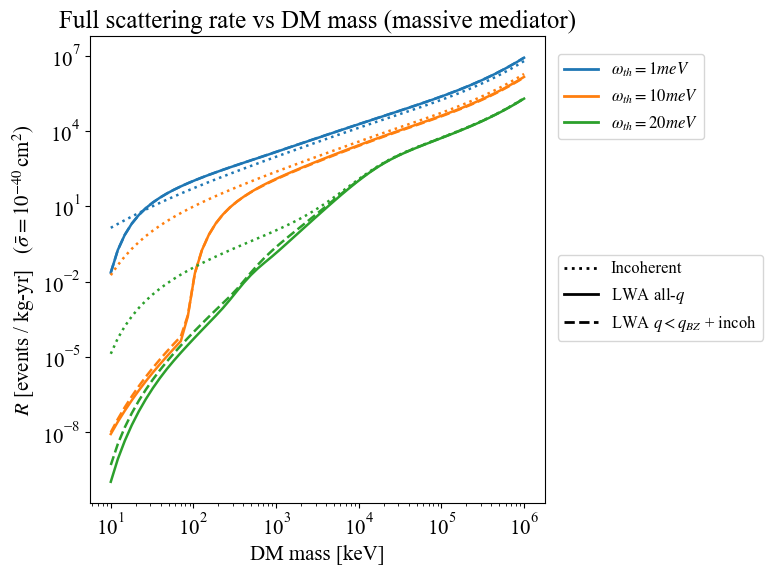

In [12]:
method_style = {'incoh': ':', 'lwa_allq': '-', 'lwa_qbz': '--'}
method_label = {'incoh': 'Incoherent', 'lwa_allq': 'LWA all-$q$', 'lwa_qbz': r'LWA $q<q_{BZ}$ + incoh'}
cut_color    = {'1 meV': 'tab:blue', '10 meV': 'tab:orange', '20 meV': 'tab:green'}

fig, ax = plt.subplots(figsize=(8, 6))
for label, R in rates_by_cut.items():
    m = R['dmmasslist']
    for meth in ('incoh', 'lwa_allq', 'lwa_qbz'):
        ax.plot(m, R[meth], color=cut_color[label], linestyle=method_style[meth], lw=1.8)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('DM mass [keV]')
ax.set_ylabel(r'$R$ [events / kg-yr]   ($\bar\sigma=10^{-40}\,$cm$^2$)')
ax.set_title('Full scattering rate vs DM mass (massive mediator)')

leg_cuts = [Line2D([0], [0], color=cut_color[l], lw=2, label=fr'$\omega_{{th}}={l}$') for l in CUTS]
leg_meth = [Line2D([0], [0], color='black', lw=2, linestyle=method_style[k], label=method_label[k])
            for k in ('incoh', 'lwa_allq', 'lwa_qbz')]
l1 = ax.legend(handles=leg_cuts, loc='upper left', bbox_to_anchor=(1.01, 0.98), fontsize=12)
ax.add_artist(l1)
ax.legend(handles=leg_meth, loc='upper left', bbox_to_anchor=(1.01, 0.55), fontsize=12)
plt.tight_layout()
plt.savefig('R_vs_dm_mass.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. (Optional) Cross-section sensitivity view — matches the manuscript figures

The manuscript plots the cross section needed for **3 events / kg-yr**, $\sigma_{3\mathrm{ev}}=3\,\bar\sigma/R$,
since $R\propto\bar\sigma$.

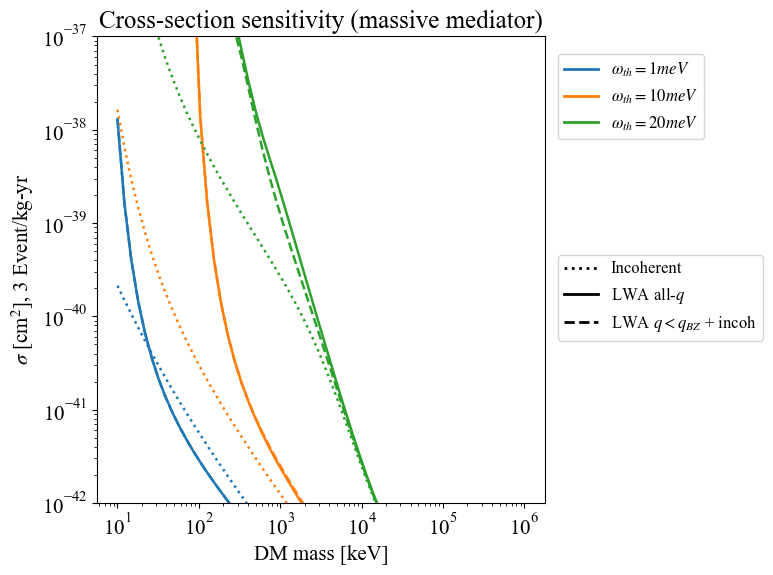

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
for label, R in rates_by_cut.items():
    m = R['dmmasslist']
    for meth in ('incoh', 'lwa_allq', 'lwa_qbz'):
        ax.plot(m, 3 * cross_section / R[meth], color=cut_color[label],
                linestyle=method_style[meth], lw=1.8)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('DM mass [keV]')
ax.set_ylabel(r'$\sigma$ [cm$^2$], 3 Event/kg-yr')
ax.set_title('Cross-section sensitivity (massive mediator)')
ax.set_ylim(1e-42, 1e-37)

l1 = ax.legend(handles=leg_cuts, loc='upper left', bbox_to_anchor=(1.01, 0.98), fontsize=12)
ax.add_artist(l1)
ax.legend(handles=leg_meth, loc='upper left', bbox_to_anchor=(1.01, 0.55), fontsize=12)
plt.tight_layout()
plt.savefig('sigma_vs_dm_mass.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Save the integrated rates

In [14]:
save_kw = {'dmmasslist': DMMASSLIST, 'cross_section': cross_section, 'q_bz': q_bz}
for label, R in rates_by_cut.items():
    tag = label.replace(' ', '')
    for meth in ('incoh', 'lwa_allq', 'lwa_qbz'):
        save_kw[f'R_{meth}_{tag}'] = R[meth]
np.savez('scattering_rate_vs_mass_masslessMediator.npz', **save_kw)
print("saved -> scattering_rate_vs_mass.npz")

saved -> scattering_rate_vs_mass.npz


In [17]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.size': 15,
    'figure.dpi': 200
})

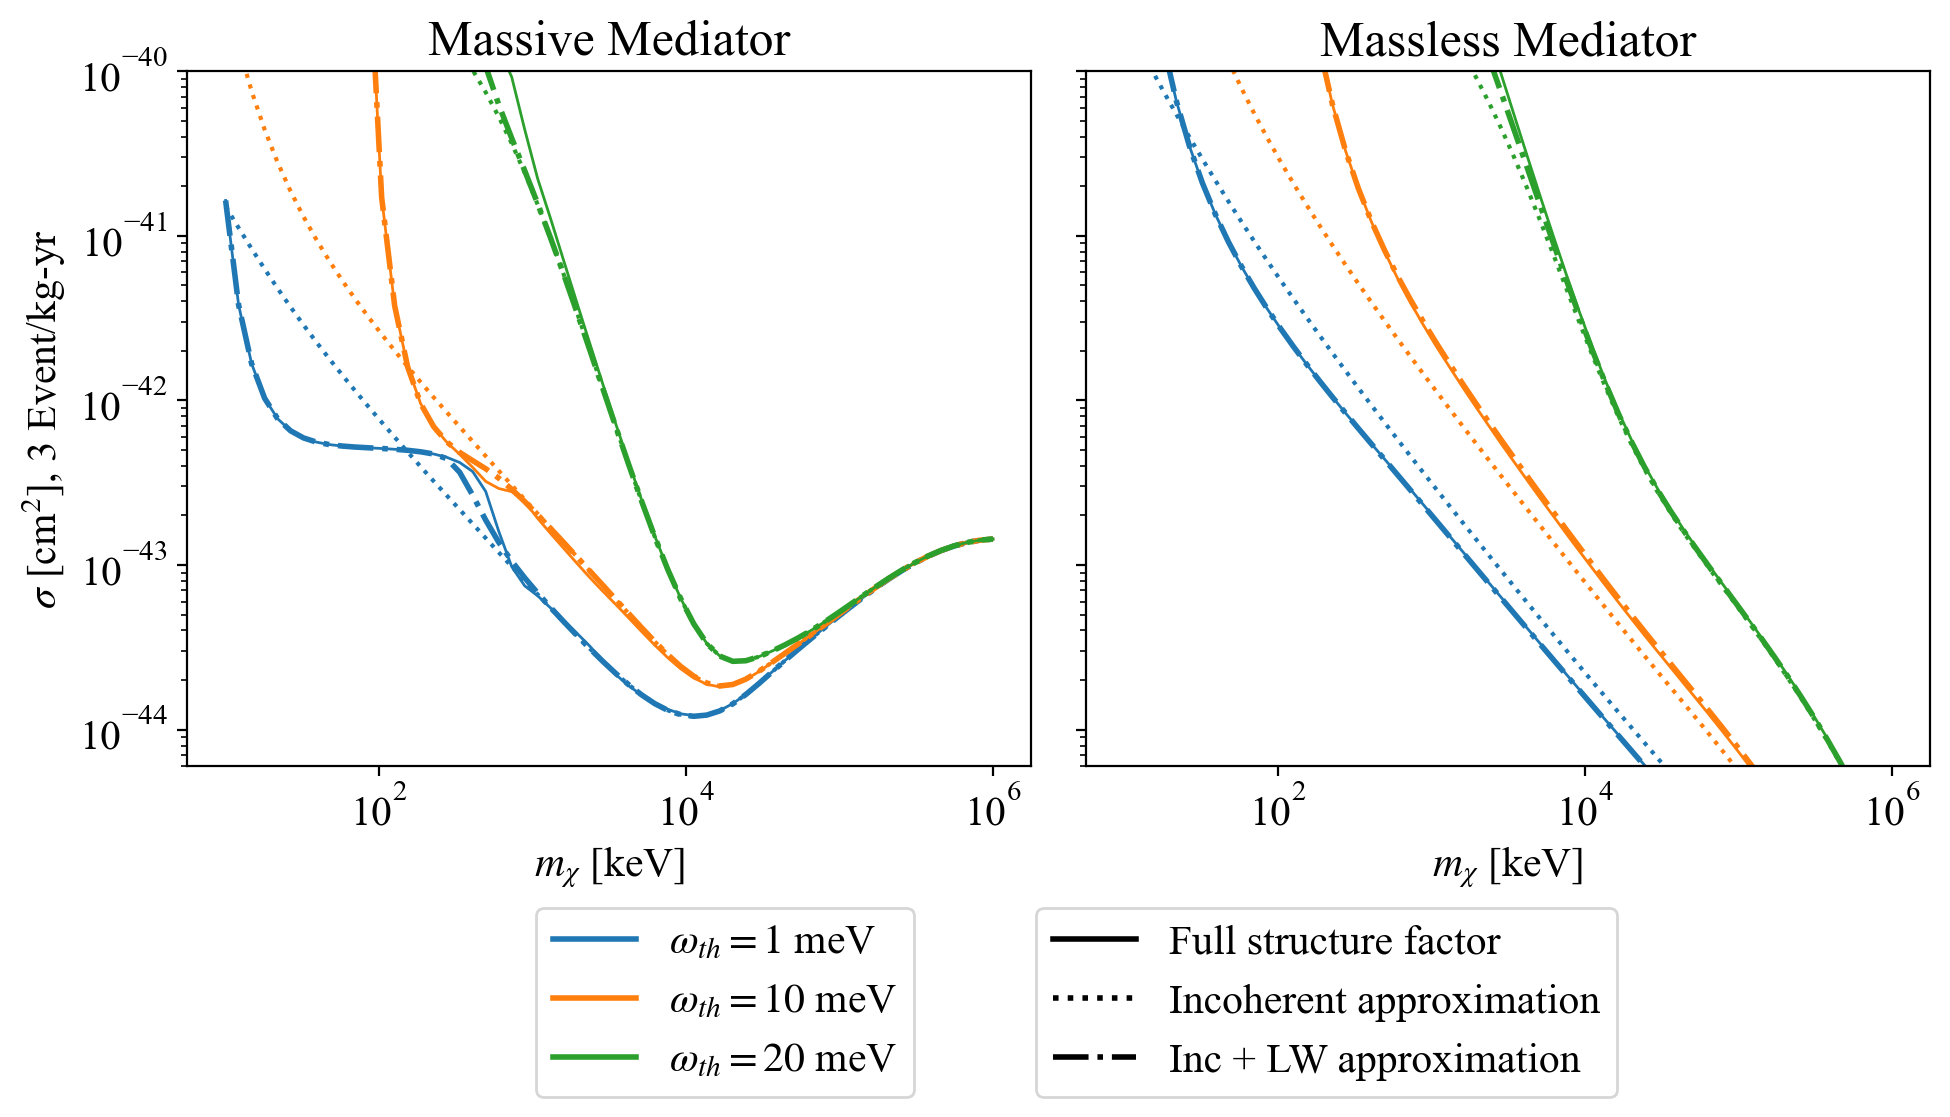

In [18]:
import numpy as np
from matplotlib.lines import Line2D

# ---------------------------------------------------------
# Cross-section sensitivity: Massive (left) vs Massless (right)
#
# Both panels use the rates_by_cut notation (methods: incoh, lwa_allq, lwa_qbz).
# Line-style mapping shared by both panels:
#     solid    'Full structure factor'     <- lwa_allq
#     dotted   'Incoherent approximation'  <- incoh
#     dash-dot 'Inc + LW approximation'    <- lwa_qbz   (LW for q < q_BZ)
#
#   - massless : in-memory `rates_by_cut` from section 9 of THIS notebook
#   - massive  : loaded from the massive-mediator notebook's saved .npz
# ---------------------------------------------------------
colors = {'1 meV': 'tab:blue', '10 meV': 'tab:orange', '20 meV': 'tab:green'}  # cut  -> color
styles = {'lwa_allq': '-', 'incoh': ':', 'lwa_qbz': '-.'}                       # method -> linestyle
lws    = {'lwa_allq': 1,   'incoh': 1.5, 'lwa_qbz': 2}                          # method -> linewidth

# --- massive results -> same dict structure as rates_by_cut ---
data = np.load('scattering_rate_vs_mass.npz')          # <- massive notebook's output file
cross_section_massive = float(data['cross_section'])   # value the massive rates were computed at
_tags = {'1 meV': '1meV', '10 meV': '10meV', '20 meV': '20meV'}
rates_by_cut_massive = {
    lab: {'dmmasslist': data['dmmasslist'],
          'incoh':    data[f'R_incoh_{t}'],
          'lwa_allq': data[f'R_lwa_allq_{t}'],
          'lwa_qbz':  data[f'R_lwa_qbz_{t}']}
    for lab, t in _tags.items()
}

def _plot_panel(ax, rates, cs):
    for cut_label, R in rates.items():
        for meth in ('lwa_allq', 'incoh', 'lwa_qbz'):
            ax.plot(R['dmmasslist'], 3 * cs / R[meth],
                    color=colors[cut_label], linestyle=styles[meth], lw=lws[meth])
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('$m_\chi$ [keV]'); ax.set_ylim(6e-45, 1e-40)

# ax2 = LEFT panel (Massive), ax1 = RIGHT panel (Massless)
fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

_plot_panel(ax1, rates_by_cut, cross_section)                 # massless (in memory)
ax1.set_title('Massless Mediator')

_plot_panel(ax2, rates_by_cut_massive, cross_section_massive) # massive (loaded)
ax2.set_title('Massive Mediator')
ax2.set_ylabel("$\sigma$ [cm$^2$], 3 Event/kg-yr")

# ---------------------------------------------------------
# Shared legends (below, 2 columns)
# ---------------------------------------------------------
legend_thresholds = [
    Line2D([0], [0], color=colors['1 meV'],  lw=2, label='$\omega_{th}=1$ meV'),
    Line2D([0], [0], color=colors['10 meV'], lw=2, label='$\omega_{th}=10$ meV'),
    Line2D([0], [0], color=colors['20 meV'], lw=2, label='$\omega_{th}=20$ meV'),
]
legend_approximations = [
    Line2D([0], [0], color='black', lw=2, linestyle=styles['lwa_allq'], label='Full structure factor'),
    Line2D([0], [0], color='black', lw=2, linestyle=styles['incoh'],    label='Incoherent approximation'),
    Line2D([0], [0], color='black', lw=2, linestyle=styles['lwa_qbz'],  label='Inc + LW approximation'),
]
fig.legend(handles=legend_thresholds,    loc='upper right', bbox_to_anchor=(0.48, 0.24))
fig.legend(handles=legend_approximations, loc='upper left',  bbox_to_anchor=(0.52, 0.24))

plt.tight_layout(rect=[0, 0.2, 1, 1])
plt.show()

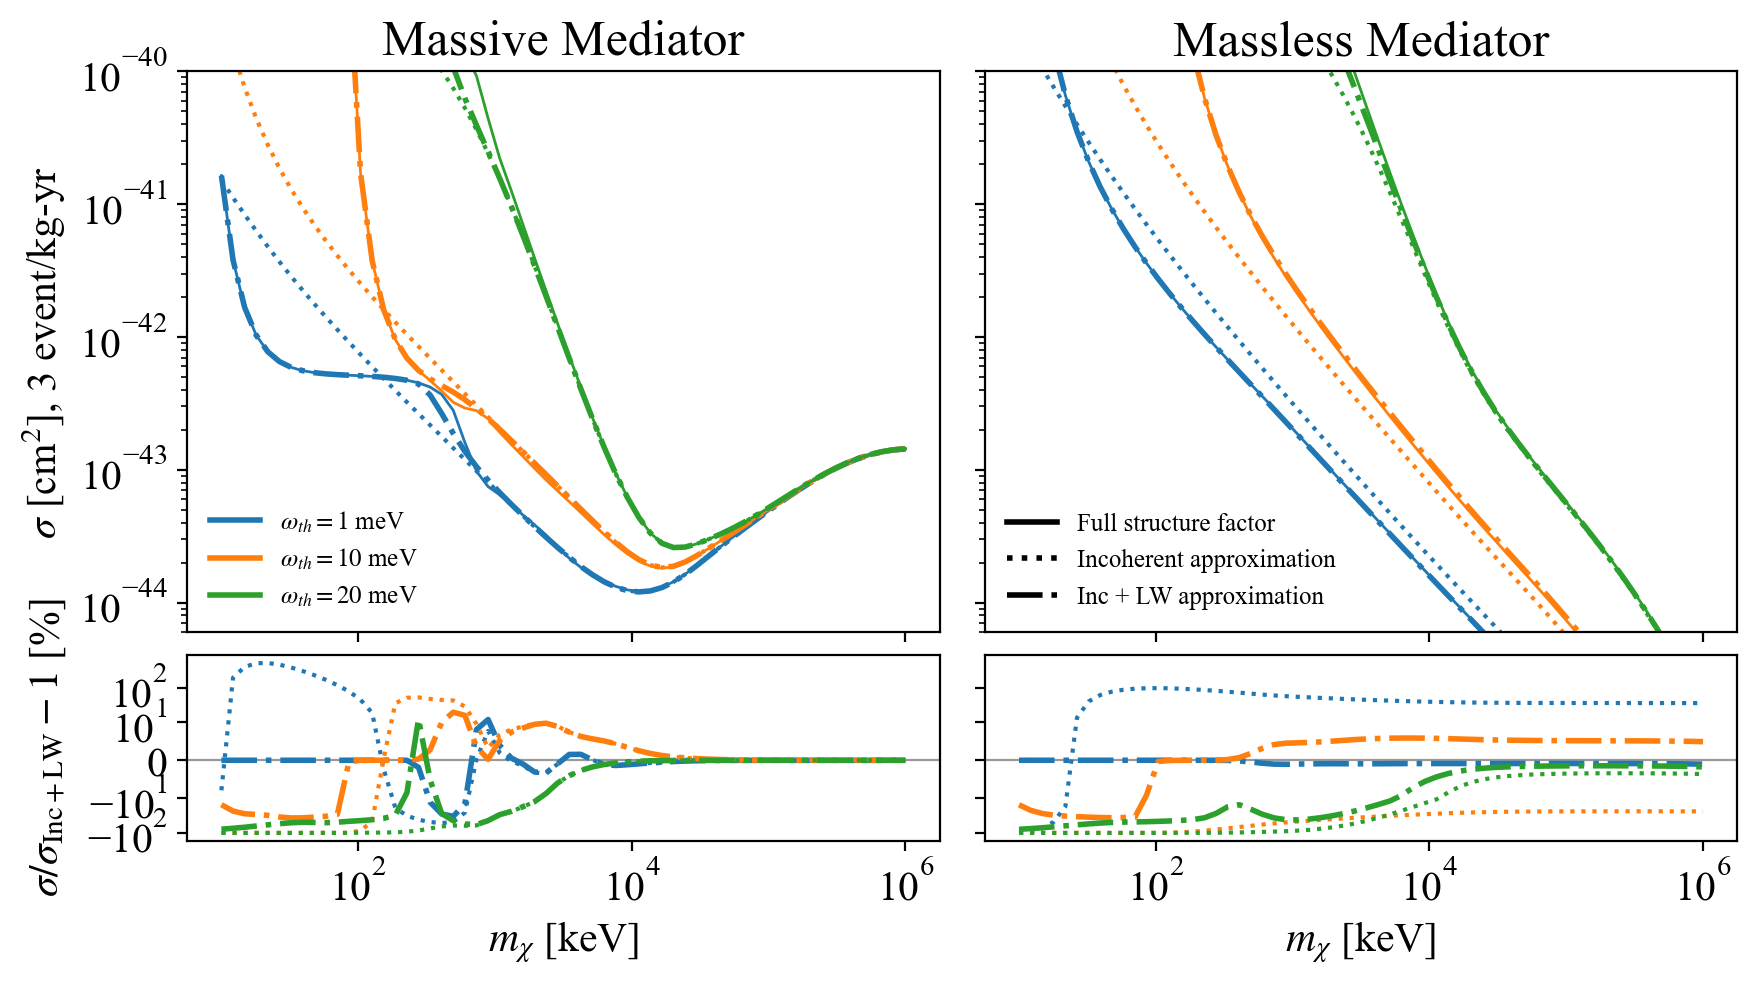

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

colors = {'1 meV': 'tab:blue', '10 meV': 'tab:orange', '20 meV': 'tab:green'}
styles = {'lwa_allq': '-', 'incoh': ':', 'lwa_qbz': '-.'}
lws    = {'lwa_allq': 1,   'incoh': 1.5, 'lwa_qbz': 2}

REF    = 'lwa_allq'                 
OTHERS = ('incoh', 'lwa_qbz')

def _sigma(R, meth, cs):
    return 3 * cs / R[meth]

def _plot_panel(ax, rates, cs):
    for cut_label, R in rates.items():
        for meth in ('lwa_allq', 'incoh', 'lwa_qbz'):
            ax.plot(R['dmmasslist'], _sigma(R, meth, cs),
                    color=colors[cut_label], linestyle=styles[meth], lw=lws[meth])
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(6e-45, 1e-40)

def _plot_resid(ax, rates, cs):
    for cut_label, R in rates.items():
        ref = _sigma(R, REF, cs)
        for meth in OTHERS:
            ax.plot(R['dmmasslist'], 100 * (_sigma(R, meth, cs) / ref - 1),
                    color=colors[cut_label], linestyle=styles[meth], lw=lws[meth])
    ax.axhline(0, color='0.6', lw=0.8, zorder=0)
    ax.set_xscale('log')
    ax.set_yscale('symlog', linthresh=10)      # drop if differences stay small
    ax.set_xlabel(r'$m_\chi$ [keV]')

fig, axes = plt.subplots(2, 2, figsize=(10, 5),
                         sharex='col', sharey='row',
                         gridspec_kw=dict(height_ratios=[3, 1],
                                          hspace=0.06, wspace=0.06))
(ax2, ax1), (rx2, rx1) = axes                  # left = massive, right = massless

_plot_panel(ax1, rates_by_cut, cross_section)
_plot_resid(rx1, rates_by_cut, cross_section)
ax1.set_title('Massless Mediator')

_plot_panel(ax2, rates_by_cut_massive, cross_section_massive)
_plot_resid(rx2, rates_by_cut_massive, cross_section_massive)
ax2.set_title('Massive Mediator')

ax2.set_ylabel(r'$\sigma$ [cm$^2$], 3 event/kg-yr')
rx2.set_ylabel(r'$\sigma/\sigma_{\rm Inc+LW}-1$ [\%]'.replace('\\%', '%'))

legend_thresholds = [Line2D([0], [0], color=colors[k], lw=2,
                            label=rf'$\omega_{{th}}={k.split()[0]}$ meV') for k in colors]
legend_approximations = [
    Line2D([0], [0], color='k', lw=2, ls=styles['lwa_allq'], label='Full structure factor'),
    Line2D([0], [0], color='k', lw=2, ls=styles['incoh'],    label='Incoherent approximation'),
    Line2D([0], [0], color='k', lw=2, ls=styles['lwa_qbz'],  label='Inc + LW approximation'),
]
ax2.legend(handles=legend_thresholds, loc='lower left', frameon=False, fontsize=9)
ax1.legend(handles=legend_approximations, loc='lower left', frameon=False, fontsize=9)

fig.align_ylabels()
plt.show()

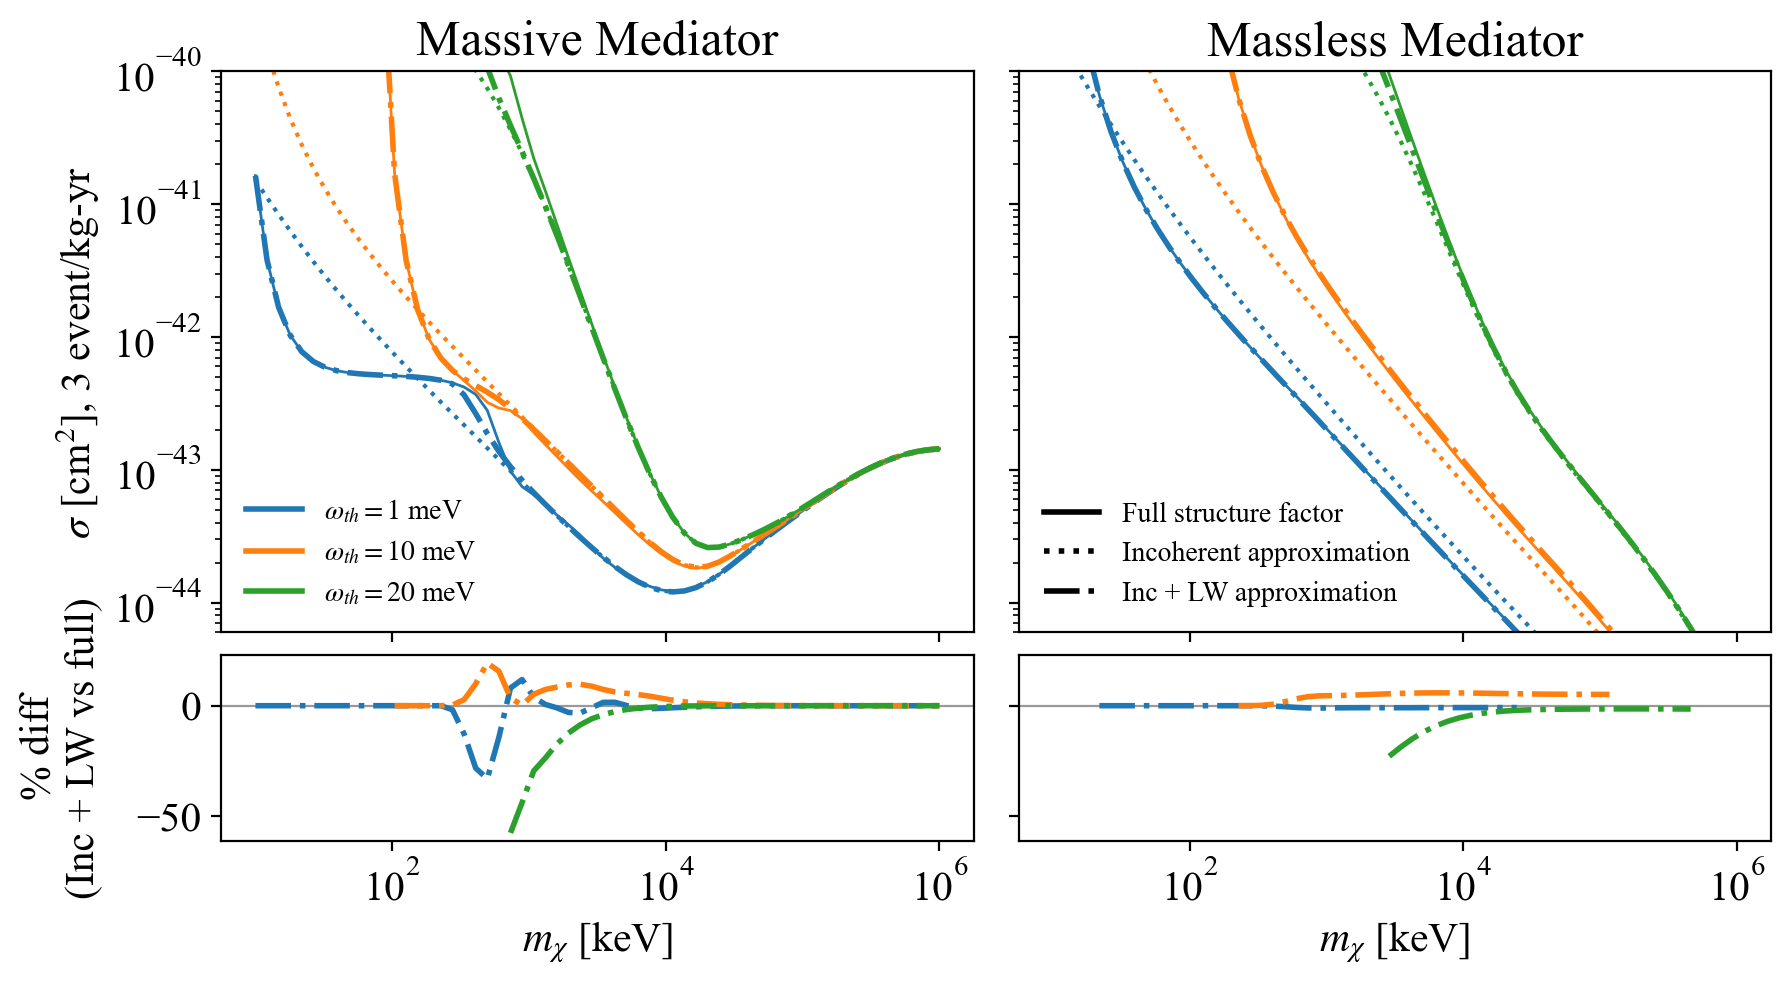

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------- style / config ----------------
colors = {'1 meV': 'tab:blue', '10 meV': 'tab:orange', '20 meV': 'tab:green'}
styles = {'lwa_allq': '-', 'incoh': ':', 'lwa_qbz': '-.'}
lws    = {'lwa_allq': 1,   'incoh': 1.5, 'lwa_qbz': 2}

REF    = 'lwa_allq'                  # full structure factor is now the baseline
OTHERS = ('lwa_qbz',)
YLIM   = (6e-45, 1e-40)

# ---------------- helpers ----------------
def _sigma(R, meth, cs):
    return 3 * cs / np.asarray(R[meth], float)

def _visible(*arrs):
    m = np.ones(np.asarray(arrs[0]).shape, dtype=bool)
    for a in arrs:
        a = np.asarray(a, float)
        m &= (a >= YLIM[0]) & (a <= YLIM[1])
    return m

def _plot_panel(ax, rates, cs):
    for cut_label, R in rates.items():
        for meth in ('lwa_allq', 'incoh', 'lwa_qbz'):
            ax.plot(R['dmmasslist'], _sigma(R, meth, cs),
                    color=colors[cut_label], linestyle=styles[meth], lw=lws[meth])
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(*YLIM)

def _plot_resid(ax, rates, cs):
    n_drawn = 0
    for cut_label, R in rates.items():
        ref = _sigma(R, REF, cs)
        for meth in OTHERS:
            cur  = _sigma(R, meth, cs)
            diff = np.where(_visible(ref, cur), 100 * (cur / ref - 1), np.nan)
            n_drawn += np.count_nonzero(~np.isnan(diff))
            ax.plot(R['dmmasslist'], diff,
                    color=colors[cut_label], linestyle=styles[meth], lw=lws[meth])
    ax.axhline(0, color='0.6', lw=0.8, zorder=0)
    ax.set_xscale('log')

    ax.set_xlabel(r'$m_\chi$ [keV]')
    return n_drawn

# ---------------- figure ----------------
fig, axes = plt.subplots(2, 2, figsize=(10, 5.),
                         sharex='col', sharey='row',
                         gridspec_kw=dict(height_ratios=[3, 1.],
                                          hspace=0.06, wspace=0.06))
(ax2, ax1), (rx2, rx1) = axes          # left = massive, right = massless

_plot_panel(ax1, rates_by_cut, cross_section)
n_r = _plot_resid(rx1, rates_by_cut, cross_section)
ax1.set_title('Massless Mediator')

_plot_panel(ax2, rates_by_cut_massive, cross_section_massive)
n_l = _plot_resid(rx2, rates_by_cut_massive, cross_section_massive)
ax2.set_title('Massive Mediator')

ax2.set_ylabel(r'$\sigma$ [cm$^2$], 3 event/kg-yr')
rx2.set_ylabel('% diff\n(Inc + LW vs full)')


if n_l + n_r == 0:
    print('warning: every residual point was masked out — check YLIM vs your sigma range')

legend_thresholds = [Line2D([0], [0], color=colors[k], lw=2,
                            label=rf'$\omega_{{th}}={k.split()[0]}$ meV') for k in colors]
legend_approximations = [
    Line2D([0], [0], color='k', lw=2, ls=styles['lwa_allq'], label='Full structure factor'),
    Line2D([0], [0], color='k', lw=2, ls=styles['incoh'],    label='Incoherent approximation'),
    Line2D([0], [0], color='k', lw=2, ls=styles['lwa_qbz'],  label='Inc + LW approximation'),
]
ax2.legend(handles=legend_thresholds, loc='lower left', frameon=False, fontsize=10)
ax1.legend(handles=legend_approximations, loc='lower left', frameon=False, fontsize=10)

fig.align_ylabels()
plt.show()